In [ ]:
import pandas as pd #numpy와 pandas는 1차원 또는 2차원 형식의 표 데이터를 다루기에 최적화된 라이브러리
import numpy as np 
import seaborn as sns #seaborn과 matplotlib 은 데이터를 시각화 특히, seaborn은 matplotlib의 상위 버전임.
import matplotlib.pyplot as plt

%matplotlib inline #주피터 노트북에서 그래프를 인라인으로 표시
%config InlineBackend.figure_format = 'retina' #고해상도 디스플레이에서 그래프를 선명하게 표시

슝=3


In [19]:
original_data = pd.read_csv('Pokemon.csv')

In [ ]:
pokemon = original_data.copy()
print(pokemon.shape) 
pokemon.head()

(800, 13)


,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [ ]:
#레전더리 열이 True인 포켓몬만 추출 그리고, 인덱스를 재설정
#legendary 포켓몬 데이터프레임 생성

legendary = pokemon[pokemon["Legendary"] == True].reset_index(drop=True)
print(legendary.shape)
legendary.head()

(65, 13)


,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,144,Articuno,Ice,Flying,580,90,85,100,95,125,85,1,True
1,145,Zapdos,Electric,Flying,580,90,90,85,125,90,100,1,True
2,146,Moltres,Fire,Flying,580,90,100,90,125,85,90,1,True
3,150,Mewtwo,Psychic,NaN,680,106,110,90,154,90,130,1,True
4,150,MewtwoMega Mewtwo X,Psychic,Fighting,780,106,190,100,154,100,130,1,True


In [ ]:
#레전더리 열이 False인 포켓몬만 추출 그리고, 인덱스를 재설정
#ordinary 포켓몬 데이터프레임 생성

ordinary = pokemon[pokemon["Legendary"] == False].reset_index(drop=True)
print(ordinary.shape)
ordinary.head()

(735, 13)


,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [ ]:
#결측치 확인 // 일단 냅두고 넘어감 하지만 기본상식으로 포켓몬은 속성2가 없는 경우가 있음.

pokemon.isnull().sum()

#               0
Name            0
Type 1          0
Type 2        386
Total           0
HP              0
Attack          0
Defense         0
Sp. Atk         0
Sp. Def         0
Speed           0
Generation      0
Legendary       0
dtype: int64

In [ ]:
# # : 포켓몬 Id number. 성별이 다르지만 같은 포켓몬인 경우 등은 같은 #값을 가진다. int
# Name : 포켓몬 이름. 포켓몬 각각의 이름으로 저장되고, 800개의 포켓몬의 이름 데이터는 모두 다르다. (unique) str
# Type 1 : 첫 번째 속성. 속성을 하나만 가지는 경우 Type 1에 입력된다. str
# Type 2 : 두 번째 속성. 속성을 하나만 가지는 포켓몬의 경우 Type 2는 NaN(결측값)을 가진다. str
# Total : 전체 6가지 스탯의 총합. int
# HP : 포켓몬의 체력. int
# Attack : 물리 공격력. (scratch, punch 등) int
# Defense : 물리 공격에 대한 방어력. int
#  Sp. Atk : 특수 공격력. (fire blast, bubble beam 등) int
# Sp. Def : 특수 공격에 대한 방어력. int
# Speed : 포켓몬 매치에 대해 어떤 포켓몬이 먼저 공격할지를 결정. (더 높은 포켓몬이 먼저 공격한다) int
# Generation : 포켓몬의 세대. 현재 데이터에는 6세대까지 있다. int
# Legendary : 전설의 포켓몬 여부. !! Target feature !! bool

In [ ]:
print(len(pokemon.columns)) #각 열이 가지는 의미에 대해서 다시 파악.
pokemon.columns

13


Index(['#', 'Name', 'Type 1', 'Type 2', 'Total', 'HP', 'Attack', 'Defense',
       'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary'],
      dtype='object')

In [ ]:
len(set(pokemon["#"]))  #총 포켓몬은 800이지만, 고유한 포켓몬은 721개임.

721

In [ ]:
pokemon[pokemon["#"] == 6] #예시로 리자몽은 X, Y 두가지 버전이 존재함.

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
6,6,Charizard,Fire,Flying,534,78,84,78,109,85,100,1,False
7,6,CharizardMega Charizard X,Fire,Dragon,634,78,130,111,130,85,100,1,False
8,6,CharizardMega Charizard Y,Fire,Flying,634,78,104,78,159,115,100,1,False


In [ ]:
len(pokemon['Name'])  #포켓몬 이름은 겹치는 것이 없이 800개임.

800

In [ ]:
pokemon.loc[[6, 10]]  #특정 행의 데이터를 확인.

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
6,6,Charizard,Fire,Flying,534,78,84,78,109,85,100,1,False
10,8,Wartortle,Water,NaN,405,59,63,80,65,80,58,1,False


In [ ]:
#포켓몬 속성의 종류 개수를 파악. list는 안써도 되지만, 이후 연산을 위해 list를 사용.

len(list(set(pokemon["Type 1"]))), len(list(set(pokemon["Type 2"]))) 

(18, 19)

In [ ]:
set(pokemon["Type 2"]) - set(pokemon["Type 1"])  #Type 2에만 존재하는 속성 확인.차집합은 nan값임.

{nan}

In [ ]:
#set이나 list를 한다고 해서 순서가 보장되지 않기 때문에, 인덱스를 출력하더라도 같은 값이 나오지 않을 수 있음.
#직접 눈으로 확인하는것이 좋다고 판단되어 unique()함수를 사용.

print(list(pokemon["Type 2"].unique()))
print(list(pokemon["Type 1"].unique()))


['Poison', nan, 'Flying', 'Dragon', 'Ground', 'Fairy', 'Grass', 'Fighting', 'Psychic', 'Steel', 'Ice', 'Rock', 'Dark', 'Water', 'Electric', 'Fire', 'Ghost', 'Bug', 'Normal']
['Grass', 'Fire', 'Water', 'Bug', 'Normal', 'Poison', 'Electric', 'Ground', 'Fairy', 'Fighting', 'Psychic', 'Rock', 'Ghost', 'Ice', 'Dragon', 'Dark', 'Steel', 'Flying']


In [ ]:
types = list(set(pokemon["Type 1"])) #포켓몬 속성 1의 종류를 리스트로 저장.
print(len(types))
print(types)

18
['Ground', 'Fairy', 'Fire', 'Ice', 'Fighting', 'Normal', 'Poison', 'Psychic', 'Ghost', 'Bug', 'Dragon', 'Flying', 'Dark', 'Water', 'Grass', 'Rock', 'Electric', 'Steel']


In [50]:
#type2가 nan인 포켓몬의 수 확인

pokemon["Type 2"].isna().sum()  #386개의 포켓몬은 type2가 없음.

386

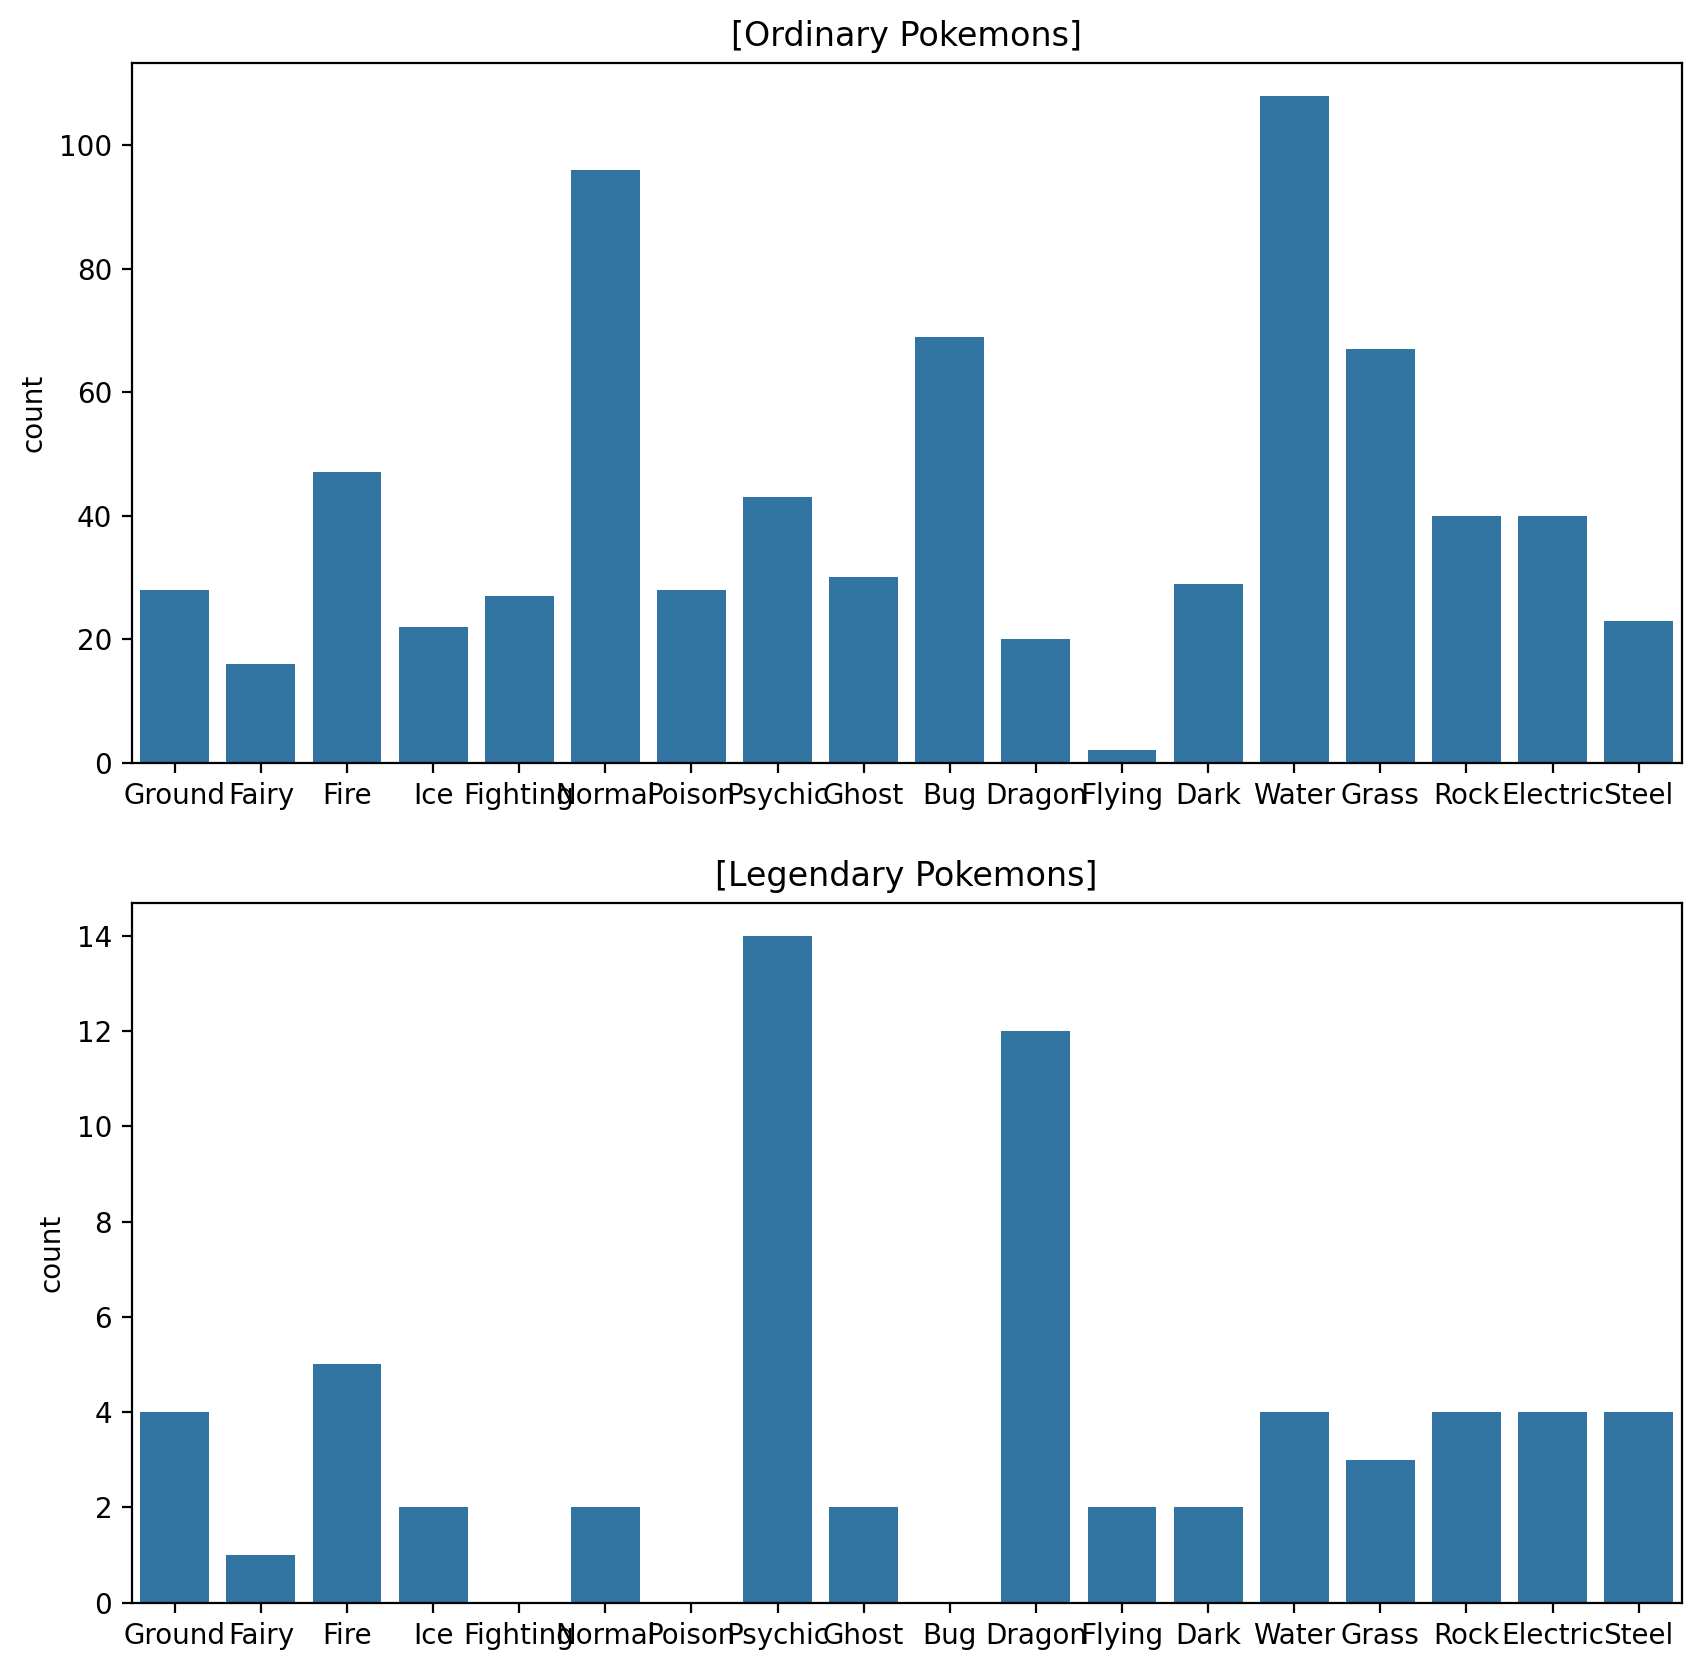

In [ ]:
plt.figure(figsize=(10, 10)) #그래프의 크기 설정

plt.subplot(211) #행/열/몇번째위치 ex) 111은 1행 1열에 1번째 위치하도록 그래프를 그려라.
sns.countplot(data=ordinary, x="Type 1", order=types).set_xlabel('') #위에서 지정한 일반포켓몬 데이터프레임을 사용하여 속성1의 개수를 세어서 그래프로 그려라. x라벨의 이름(즉, type1)을 제거. 그래야 깔끔.
plt.title("[Ordinary Pokemons]") #그래프의 제목 설정.

plt.subplot(212) 
sns.countplot(data=legendary, x="Type 1", order=types).set_xlabel('')
plt.title("[Legendary Pokemons]")

plt.show() #자동랜더링 기능때문에 생략가능하지만, 명시적으로 코드를 보기 편함.

In [ ]:
#피벗테이블을 사용하여 포켓몬 속성 1별 레전더리 비율 확인
#50%가 Flying 속성임.

pd.pivot_table(pokemon, index="Type 1", values="Legendary").sort_values(by=["Legendary"], ascending=False)
# 포켓몬을 Type 1 기준으로 그룹화하고, 각 타입의 전설 포켓몬 비율(평균)을 계산한 뒤, 전설 비율이 높은 순으로 정렬


,Legendary
Type 1,
Flying,0.500000
Dragon,0.375000
Psychic,0.245614
Steel,0.148148
Ground,0.125000
Fire,0.096154
Electric,0.090909
Rock,0.090909
Ice,0.083333


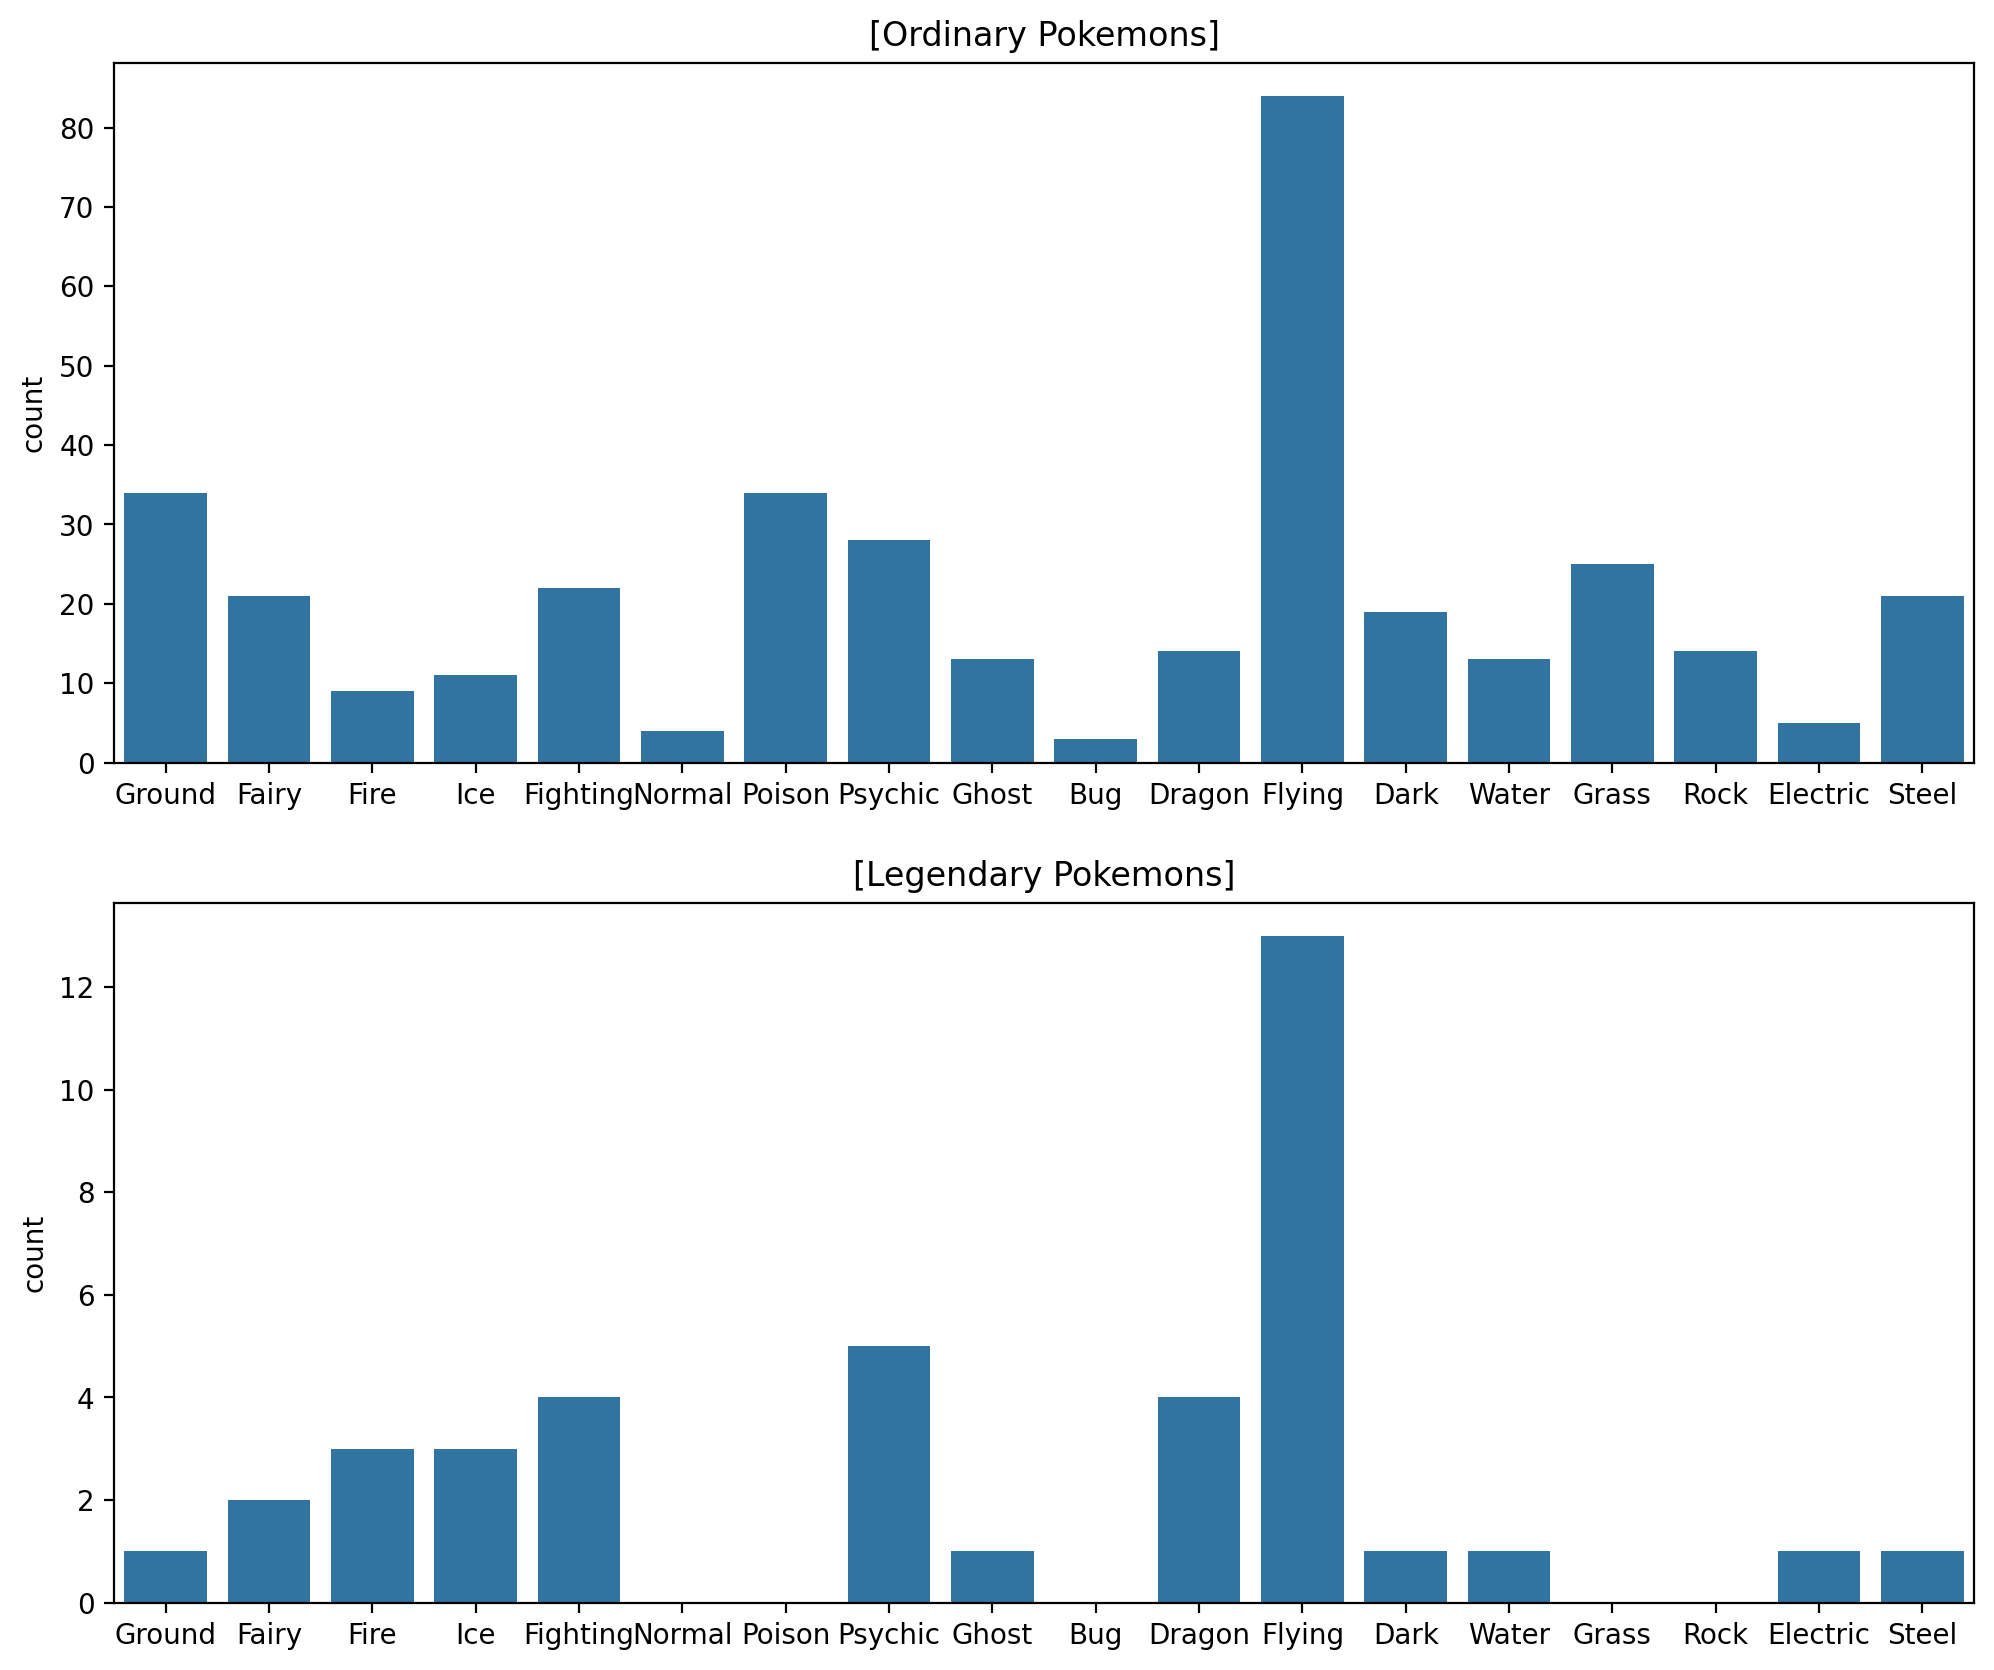

In [76]:
plt.figure(figsize=(12, 10))  # 화면 해상도에 따라 그래프 크기를 조정해 주세요.

plt.subplot(211)
sns.countplot(data=ordinary, x="Type 2", order=types).set_xlabel('')
plt.title("[Ordinary Pokemons]")

plt.subplot(212)
sns.countplot(data=legendary, x="Type 2", order=types).set_xlabel('')
plt.title("[Legendary Pokemons]")

plt.show()

In [ ]:
#피벗테이블을 사용하여 포켓몬 속성 2별 일반포켓몬 비율 확인
#포켓몬을 Type 2 기준으로 그룹화하고, 각 타입의 전설 포켓몬 비율(평균)을 계산한 뒤, 전설 비율이 높은 순으로 정렬

pd.pivot_table(pokemon, index="Type 2", values="Legendary").sort_values(by=["Legendary"], ascending=False)

,Legendary
Type 2,
Fire,0.250000
Dragon,0.222222
Ice,0.214286
Electric,0.166667
Fighting,0.153846
Psychic,0.151515
Flying,0.134021
Fairy,0.086957
Water,0.071429


In [81]:
stats = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]
stats

['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']

In [82]:
df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [83]:
print("#0 pokemon: ", pokemon.loc[0, "Name"])
print("total: ", int(pokemon.loc[0, "Total"]))
print("stats: ", list(pokemon.loc[0, stats]))
print("sum of all stats: ", sum(list(pokemon.loc[0, stats])))

#0 pokemon:  Bulbasaur
total:  318
stats:  [45, 49, 49, 65, 65, 45]
sum of all stats:  318


In [92]:
pokemon[stats].sum(axis=1) 

0      318
1      405
2      525
3      625
4      309
      ... 
795    600
796    700
797    600
798    680
799    600
Length: 800, dtype: int64